# Step 6 and 7 - setup 


In [6]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path
import matplotlib.cm as cm
from matplotlib.patches import Polygon, Patch, Rectangle
from scipy.spatial import ConvexHull
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.metrics import pairwise_distances

In [ ]:
#names of the dot files that contain the data:
data_name_1 = "../Datasets/JazzNetwork.dot"
data_name_2 = "../Datasets/LesMiserables.dot"
data_name_3 = "../Datasets/devonshiredebate_withclusters.dot"
data_name_4 = "../Datasets/g.20.27.dot"
data_name_5 = "../Datasets/g.42.88.dot"
data_name_6 = "../Datasets/GD97.dot"
data_name_7 = "../Datasets/LeagueNetwork.dot" 
data_name_8 = "../Datasets/mesh graph.dot"
data_name_9 = "../Datasets/noname.dot" 
data_name_10 = "../Datasets/polblogs.dot"
data_name_11 = "../Datasets/robot graph.dot"
data_name_12 = "../Datasets/rome.dot"
data_name_13 = "../Datasets/snail graph.dot"

## Functions

In [10]:
def data_processing(data_name):
    """
    Processes the input data file and returns a list of nodes and edges adm their dictionaries.
    
    Input:
    - data_name: The name of the input data file (DOT format)
    """
    # Load the graph directly with NetworkX
    dataforfile = os.path.basename(data_name) #used for file creation
    nx_graph = nx.nx_pydot.read_dot(data_name)

    # Check graph type
    is_directed = nx.is_directed(nx_graph)
    print(f"Graph is {'directed' if is_directed else 'undirected'}")

    # Extract nodes and edges and their attributes
    nodes = nx_graph.nodes(data=True)
    edges = nx_graph.edges(data=True)

    # Create an array of dictionaries, one for each edge
    edges_dict = []
    for source, target, attrs in edges:
        # Add the original edge direction
        edge_dict = {
            "edge_nodes": (source, target),
            "directed": is_directed
        }

        # Add all attributes from the attrs dictionary
        for attr_name, attr_value in attrs.items():    
            edge_dict[attr_name] = attr_value

        edges_dict.append(edge_dict)

        # For undirected graphs, add the reverse edge as well
        if not is_directed:
            reverse_edge_dict = {
                "edge_nodes": (target, source),
                "directed": is_directed
            }

            # Copy all attributes from the original edge
            for attr_name, attr_value in attrs.items():    
                reverse_edge_dict[attr_name] = attr_value

            edges_dict.append(reverse_edge_dict)

    nodes_dict = []
    for node_id, attrs in nodes:
        node_dict = {
            "node_id": node_id
        }

        # Add all attributes from the attrs dictionary
        for attr_name, attr_value in attrs.items():        
            node_dict[attr_name] = attr_value

        nodes_dict.append(node_dict)

    # Basic graph information
    print(f"Number of nodes: {len(nodes)}")
    if is_directed:
        print(f"Number of edges: {len(edges)}")
    else:
        print(f"Original Number of Edges:  {len(edges)} \n -- after doubling edges -- \nNumber of edges: {len(edges) * (2 if not is_directed else 1)}")

    return nodes_dict, edges_dict, nodes, edges


def floyd_warshall(nodes_dict, edges_dict):
    """
    Implements the Floyd-Warshall algorithm to find shortest paths between all pairs of nodes in a graph.
    
    Input:
    - nodes_dict: A list of dictionaries where each dict contains 'node_id' and other attributes
    - edges_dict: A list of dictionaries where each dict contains 'edge_nodes' (source, target) tuple
                  and other attributes including possibly weight information
    
    Output:
    - distance_matrix: A 2D matrix where distance_matrix[i][j] is the shortest path distance from node i to node j
    - node_ids: The list of node IDs in the order they appear in the distance matrix
    
    Algorithm explanation:
    The Floyd-Warshall algorithm finds shortest paths between all pairs of nodes by:
    1. Initializing a distance matrix D with infinity for all non-adjacent nodes
    2. Setting D[i,i] = 0 for all nodes (distance from a node to itself)2
    3. Setting D[i,j] = weight for each direct edge (i,j)
    4. Considering each node k as a potential intermediate in paths between i and j
    5. If going through k yields a shorter path, updating D[i,j] accordingly
    
    Time Complexity: O(|V|³) where |V| is the number of nodes
    """
    
    # Extract node IDs from nodes_dict
    node_ids = [node['node_id'] for node in nodes_dict]
    n = len(node_ids)
    
    # Create node to index mapping for the matrix
    node_to_idx = {node_id: i for i, node_id in enumerate(node_ids)}
    
    # Initialize distance matrix with infinity
    distance_matrix = [[float('inf') for _ in range(n)] for _ in range(n)]
    
    # Set diagonal elements to 0 (distance from a node to itself)
    for i in range(n):
        distance_matrix[i][i] = 0
    
    # Set edge weights
    for edge in edges_dict:
        source, target = edge['edge_nodes']
        
        # Clean up node IDs (remove quotes if present)
        source = source.strip('"')
        target = target.strip('"')
        
        if source in node_to_idx and target in node_to_idx:
            # Determine the weight - look for a weight attribute, default to 1 if not found
            weight = 1
            if 'weight' in edge:
                try:
                    weight = float(edge['weight'].strip('"'))
                except (ValueError, AttributeError):
                    weight = 1
            elif 'len' in edge:
                try:
                    weight = float(edge['len'].strip('"'))
                except (ValueError, AttributeError):
                    weight = 1
                
            i, j = node_to_idx[source], node_to_idx[target]
            distance_matrix[i][j] = weight
            
            # If the graph is undirected, add the reverse edge as well
            # Uncomment this if your graph is undirected
            # distance_matrix[j][i] = weight
    
    # Floyd-Warshall algorithm
    for k in range(n):
        for i in range(n):
            for j in range(n):
                if distance_matrix[i][j] > distance_matrix[i][k] + distance_matrix[k][j]:
                    distance_matrix[i][j] = distance_matrix[i][k] + distance_matrix[k][j]
    
    return distance_matrix, node_ids
    
def plot_coloured_distance_matrix(distance_matrix, node_ids=None, cmap='viridis_r', figsize=(10, 8)):
    """
    Visualizes the distance matrix from Floyd-Warshall algorithm as a heatmap with annotations.
    
    Parameters:
    - distance_matrix: 2D matrix of shortest path distances between all pairs of nodes
    - node_ids: List of node IDs in the order they appear in the distance matrix (optional)
    - cmap: Colormap to use for the heatmap (default: 'viridis_r')
    - figsize: Figure size (width, height) in inches
    
    Returns:
    - matplotlib figure and axes objects
    """
    
    # Convert to numpy array if not already
    distance_matrix = np.array(distance_matrix)
    
    # Create a masked array for infinity values
    mask = np.isinf(distance_matrix)
    masked_matrix = np.ma.masked_array(distance_matrix, mask)
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot heatmap
    im = ax.imshow(masked_matrix, cmap=cmap)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Shortest Path Distance')
    
    # Set title and labels
    ax.set_title('Shortest Path Distances (Floyd-Warshall Algorithm)')
    
    if node_ids is not None:
        # Clean node IDs (remove quotes if present)
        clean_node_ids = [nid.strip('"') if isinstance(nid, str) else nid for nid in node_ids]
        
        # Only show node labels if there are not too many
        if len(node_ids) <= 30:
            ax.set_xticks(np.arange(len(node_ids)))
            ax.set_yticks(np.arange(len(node_ids)))
            ax.set_xticklabels(clean_node_ids, rotation=45, ha='right')
            ax.set_yticklabels(clean_node_ids)
    
    ax.set_xlabel('Destination Node')
    ax.set_ylabel('Source Node')
    
    # Add text annotations with distances
    if distance_matrix.shape[0] <= 20:  # Only add annotations for smaller matrices
        for i in range(distance_matrix.shape[0]):
            for j in range(distance_matrix.shape[1]):
                value = distance_matrix[i, j]
                text = 'Inf' if np.isinf(value) else f'{value:.1f}'
                text_color = 'white' if not np.isinf(value) and value > np.nanmean(masked_matrix) else 'black'
                ax.text(j, i, text, ha='center', va='center', color=text_color)
    
    # Add a grid to better separate cells
    ax.set_xticks(np.arange(distance_matrix.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(distance_matrix.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=1)
    
    plt.tight_layout()
    return fig, ax

def folder_for_projections(file_name):
    # Define the base output directory one level up from current directory
    parent_dir = os.path.dirname(os.getcwd())
    output_dir = os.path.join(parent_dir, "Step6_outputs-" + file_name[11:])

    # Define subdirectories
    subdirs = ["MDS", "tSNE", "ISOMAP"]

    # Create main output directory if it doesn't exist
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created main directory: {output_dir}")

    # Create subdirectories
    for subdir in subdirs:
        subdir_path = os.path.join(output_dir, subdir)
        if not os.path.exists(subdir_path):
            os.makedirs(subdir_path)
            print(f"Created directory: {subdir_path}")

        # Create 2D and 3D folders inside ISOMAP
        if subdir == "ISOMAP":
            for dimension in ["2D", "3D"]:
                dimension_path = os.path.join(subdir_path, dimension)
                if not os.path.exists(dimension_path):
                    os.makedirs(dimension_path)
                    print(f"Created directory: {dimension_path}")
        
    return output_dir

def mds_2d_projection(distance_matrix, node_ids, edges, output_dir):
    """
    Performs MDS projection on the distance matrix and saves the results.
    
    Input:
    - distance_matrix: The distance matrix from floyd_warshall
    - node_ids: The list of node IDs from floyd_warshall
    - output_dir: Directory to save the MDS plot
    - n_components: Number of dimensions for MDS (default is 2)
    
    Output:
    - 
    """ 
    mds = MDS(n_components=2, dissimilarity='precomputed')

    # Fit the MDS model to your data
    mds_distance_matrix_reduced = mds.fit_transform(distance_matrix)

    print('Dimesnion of X after MDS = ',mds_distance_matrix_reduced.shape)

    # Plot the reduced data
    plt.figure(figsize=(10, 8))
    plt.scatter(mds_distance_matrix_reduced[:, 0], mds_distance_matrix_reduced[:, 1], s=50)

    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')

        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)

        # Get the coordinates of the source and target nodes
        source_coords = mds_distance_matrix_reduced[source_idx]
        target_coords = mds_distance_matrix_reduced[target_idx]

        # Plot the edge
        plt.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], 'k-', alpha=0.1)

    # Add labels for each point
    for i in range(len(mds_distance_matrix_reduced)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        plt.annotate(node_label, 
                     (mds_distance_matrix_reduced[i, 0], mds_distance_matrix_reduced[i, 1]), 
                     fontsize=12)

    plt.title("MDS of the Distance Matrix \n n_components = 2")
    plt.xlabel("First MDS Component")
    plt.ylabel("Second MDS Component")
    plt.grid(True)

    # Save the plot
    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('mds_visualization_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1

    # Save the plot with incremental number
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, f"MDS/mds_visualization_{file_number}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Show the plot after saving
    plt.show()

    print(f"Plot saved as: {output_file}")

    return mds_distance_matrix_reduced

def tsne_2d_projection(distance_matrix_np, node_ids, edges, output_dir, perplexity, angle):
    tsne = TSNE(
        n_components=2,           # Reduced to 2 dimensions
        metric='precomputed',     # This is crucial - tells t-SNE we're providing distances
        learning_rate='auto',     
        init='random',            
        perplexity= perplexity,  # Default is 30
        angle=angle,  
        random_state=42)

    # Apply t-SNE to the NumPy array version of the distance matrix
    tsne_distance_matrix_reduced = tsne.fit_transform(distance_matrix_np)
    print('Dimesnion of X after t-SNE = ', tsne_distance_matrix_reduced.shape)
    # Get t-SNE parameters for the title
    tsne_params = f"perplexity={tsne.perplexity}, learning_rate={tsne.learning_rate}, n_components={tsne.n_components}, method={tsne.method}"
    # Visualize the result
    plt.figure(figsize=(10, 8))
    plt.scatter(tsne_distance_matrix_reduced[:, 0], tsne_distance_matrix_reduced[:, 1], s=100)
    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')
        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)
        # Get the coordinates of the source and target nodes
        source_coords = tsne_distance_matrix_reduced[source_idx]
        target_coords = tsne_distance_matrix_reduced[target_idx]
        # Plot the edge
        plt.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], 'k-', alpha=0.1)
    
    # Add labels for each point
    for i in range(len(tsne_distance_matrix_reduced)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        plt.annotate(node_label, 
                     (tsne_distance_matrix_reduced[i, 0], tsne_distance_matrix_reduced[i, 1]), 
                     fontsize=12)
    plt.title(f't-SNE Projection of Distance Matrix\n({tsne_params})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    
    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('tSNE_visualization_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1
    
    # Save the plot with incremental number
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, f"tSNE/tsne_visualization_{file_number}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Show the plot after saving
    plt.show()
    print(f"Plot saved as: {output_file}")

    return tsne_distance_matrix_reduced


def isomap_2d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors = 60):

    # Create Isomap object
    isomap = Isomap(
        n_components=2,          # Reduce to 2 dimensions
        metric='precomputed',    # Indicate we're using a precomputed distance matrix
        n_neighbors=n_neighbors          # Number of neighbors to consider for each point
    )

    # Apply Isomap to the distance matrix
    isomap_results = isomap.fit_transform(distance_matrix_np)
    print('Dimension of X after Isomap =', isomap_results.shape)

    # Get ISOMAP parameters for the title
    isomap_params = f"n_components={isomap.n_components}, n_neighbors={isomap.n_neighbors}"

    # Visualize the results
    plt.figure(figsize=(10, 8))
    plt.scatter(isomap_results[:, 0], isomap_results[:, 1], s=100)

    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')

        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)

        # Get the coordinates of the source and target nodes
        source_coords = isomap_results[source_idx]
        target_coords = isomap_results[target_idx]

        # Plot the edge
        plt.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], 'k-', alpha=0.1)

    # Add labels for each point
    for i in range(len(isomap_results)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        plt.annotate(node_label, 
                    (isomap_results[i, 0], isomap_results[i, 1]), 
                    fontsize=12)

    plt.title(f'ISOMAP Projection of Distance Matrix\n({isomap_params})')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    plt.tight_layout()
    
    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('"ISOMAP/2D/ISOMAP_visualization_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1

    # Save the plot with incremental number and parameters
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, 
                              f"ISOMAP/2D/ISOMAP_visualization_{file_number}_comp{isomap.n_components}_neigh{isomap.n_neighbors}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    # Show the plot after saving
    plt.show()

    print(f"Plot saved in 2D folder as: {output_file}")

    return isomap_results


def isomap_3d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors=60):

    # Create Isomap object
    isomap = Isomap(
        n_components=3,          # Reduce to 3 dimensions
        metric='precomputed',    # Indicate we're using a precomputed distance matrix
        n_neighbors= n_neighbors            # Number of neighbors to consider for each point
    )

    # Apply Isomap to the distance matrix
    isomap_results = isomap.fit_transform(distance_matrix_np)
    print('Dimension of X after Isomap =', isomap_results.shape)


    # plot isomap 3D with possibility to rotate the view point
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(isomap_results[:, 0], isomap_results[:, 1], isomap_results[:, 2], s=50)

    # add edges
    for edge in edges:
        source, target, _ = edge
        source = source.strip('"')
        target = target.strip('"')

        # Get the indices of the source and target nodes
        source_idx = node_ids.index(source)
        target_idx = node_ids.index(target)

        # Get the coordinates of the source and target nodes
        source_coords = isomap_results[source_idx]
        target_coords = isomap_results[target_idx]

        # Plot the edge
        ax.plot([source_coords[0], target_coords[0]], [source_coords[1], target_coords[1]], [source_coords[2], target_coords[2]], 'k-', alpha=0.2)

    # Add labels for each point
    for i in range(len(isomap_results)):
        node_label = str(i+1)  # Adjust if you have actual node IDs
        ax.text(isomap_results[i, 0], isomap_results[i, 1], isomap_results[i, 2], node_label, fontsize=6)

    # Get ISOMAP parameters for the title
    isomap_params = f"n_components={isomap.n_components}, n_neighbors={isomap.n_neighbors}"

    # Set title and labels
    ax.set_title(f'3D ISOMAP Projection\n({isomap_params})')
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_zlabel('Dimension 3')

    # Function to get next available file number
    def get_next_file_number():
        existing_files = [f for f in os.listdir(output_dir) 
                         if f.startswith('ISOMAP/3D/ISOMAP_3D_') and f.endswith('.png')]
        if not existing_files:
            return 1
        numbers = [int(f.split('_')[2].split('.')[0]) for f in existing_files]
        return max(numbers) + 1

    # Save the plot with incremental number and parameters
    file_number = get_next_file_number()
    output_file = os.path.join(output_dir, 
                              f"ISOMAP/3D/ISOMAP_3D_{file_number}_comp{isomap.n_components}_neigh{isomap.n_neighbors}.png")
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

    plt.show()

    print(f"3D plot saved as: {output_file}")

    return isomap_results

# Usage Step 6:

## take the input graph and compute similarity matrix using graph-theoretic distance

Graph is undirected
Number of nodes: 77
Original Number of Edges:  254 
 -- after doubling edges -- 
Number of edges: 508


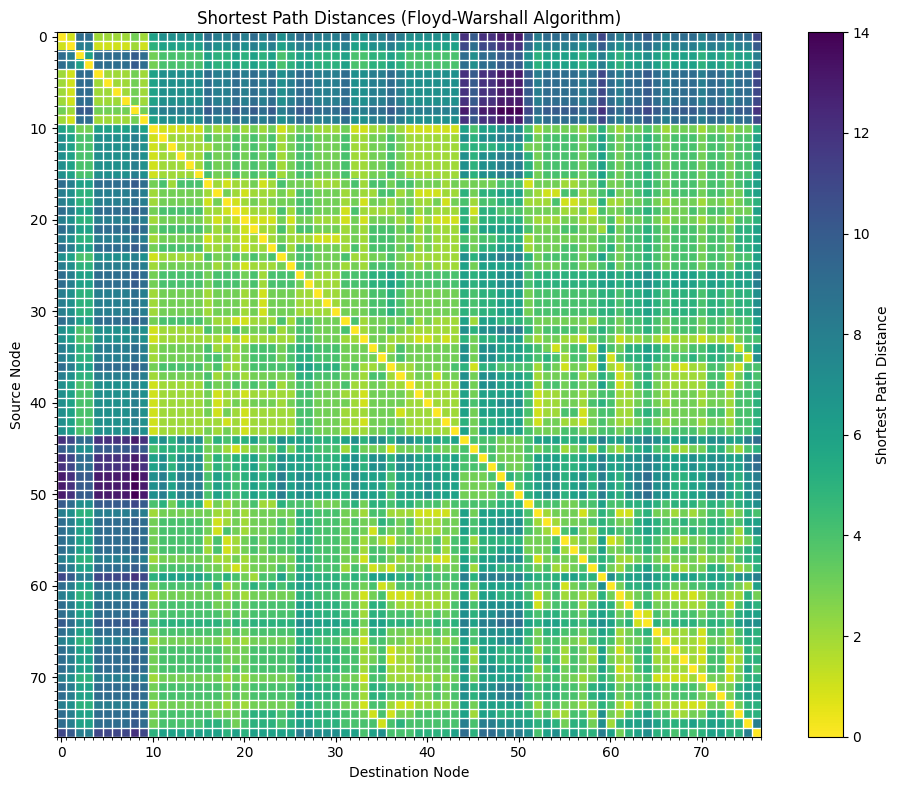

In [13]:
file_name = data_name_2
nodes_dict, edges_dict, nodes, edges = data_processing(data_name_2)
distance_matrix, node_ids = floyd_warshall(nodes_dict, edges_dict)
fig, ax = plot_coloured_distance_matrix(distance_matrix, node_ids)
plt.show()

## project it using at least two different projections (MDS, t-SNE, ISOMAP)

Preliminary adjustments on the distance matrix format and create a folder to store the results in:

In [14]:
# Convert the distance matrix to a NumPy array (for t-SNE and ISOMAP) and creates a folder to store the projections
distance_matrix_np = np.array(distance_matrix)

output_dir = folder_for_projections(file_name)

### MDS

Dimesnion of X after MDS =  (77, 2)


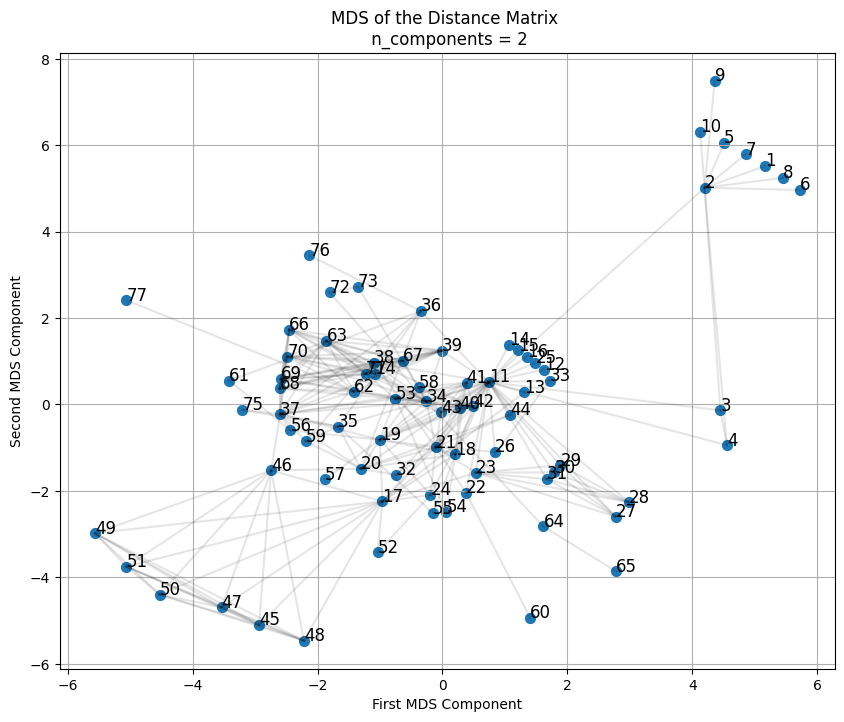

Plot saved as: /Users/edo/Desktop/UniTrieste/2°sem_2°anno/erasmus/01_Data_Visualization/project/step_6/Data-Visualization-CurryPasta/Step6_outputs-LesMiserables.dot/MDS/mds_visualization_1.png


In [15]:
mds_distance_matrix_reduced = mds_2d_projection(distance_matrix, node_ids, edges, output_dir)

### t-SNE

In [16]:
# Define the perplexity range based on the number of nodes
lower = max(2, int(0.05 * len(node_ids))) # 5%
upper = max(3, int(0.10 * len(node_ids))) # 10%

print(f"Adviced perplexity range: {lower} to {upper}")

Adviced perplexity range: 3 to 7


Dimesnion of X after t-SNE =  (77, 2)


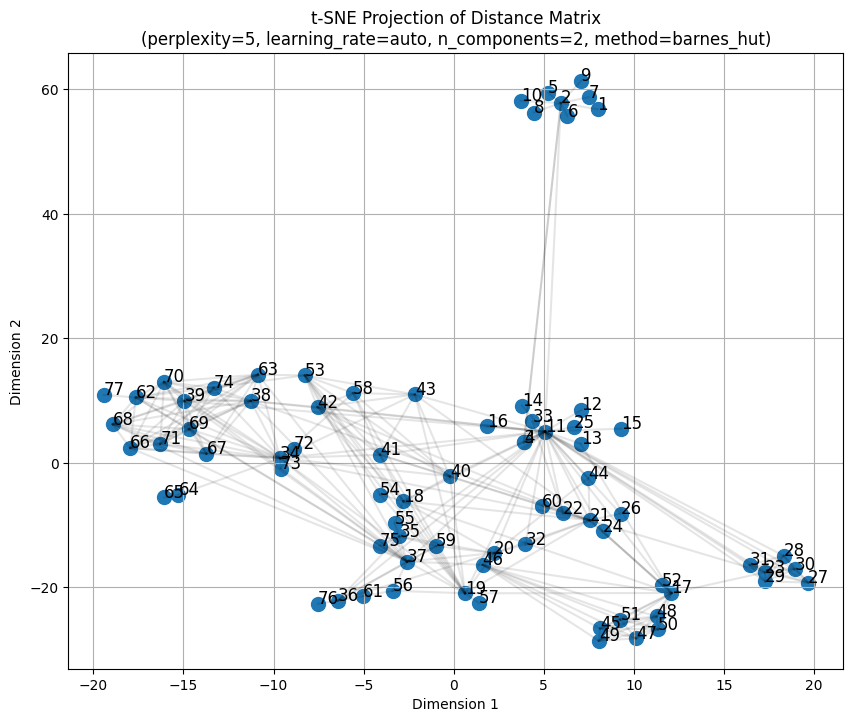

Plot saved as: /Users/edo/Desktop/UniTrieste/2°sem_2°anno/erasmus/01_Data_Visualization/project/step_6/Data-Visualization-CurryPasta/Step6_outputs-LesMiserables.dot/tSNE/tsne_visualization_1.png


In [17]:
tsne_distance_matrix_reduced = tsne_2d_projection(distance_matrix_np, node_ids, edges, output_dir, perplexity=5, angle=0.5)

### ISOMAP 2D

Dimension of X after Isomap = (77, 2)


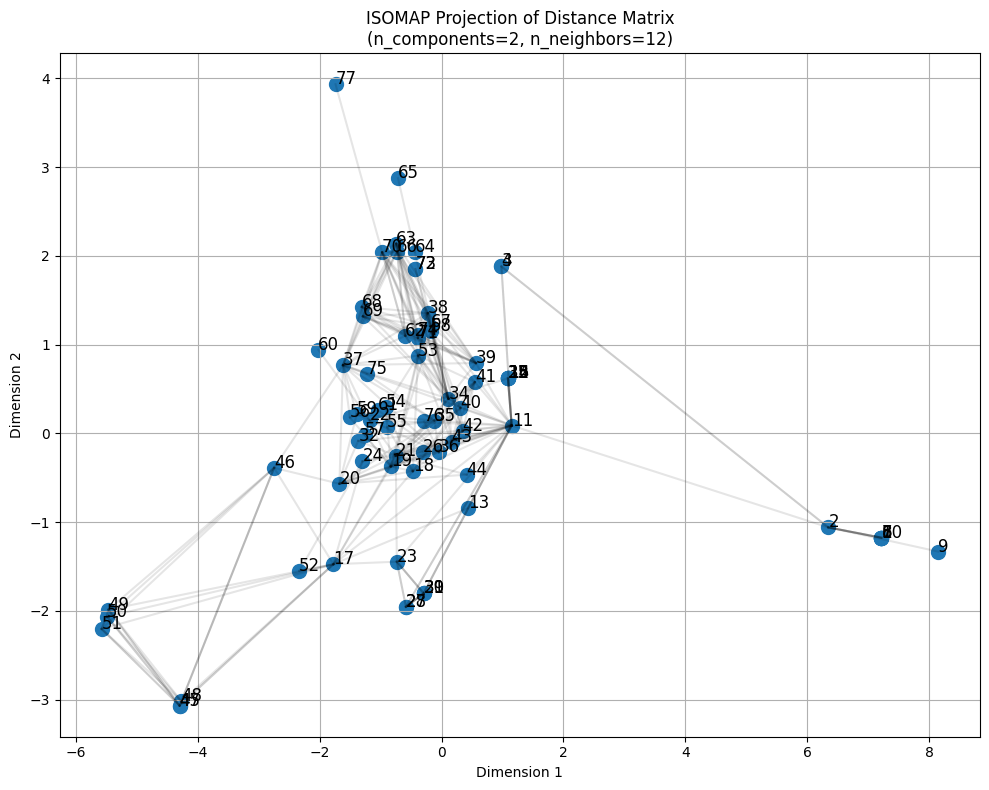

Plot saved in 2D folder as: /Users/edo/Desktop/UniTrieste/2°sem_2°anno/erasmus/01_Data_Visualization/project/step_6/Data-Visualization-CurryPasta/Step6_outputs-LesMiserables.dot/ISOMAP/2D/ISOMAP_visualization_1_comp2_neigh12.png


In [20]:
isomap_distance_matrix_reduced_2d = isomap_2d_projection(distance_matrix_np, node_ids, edges, output_dir, n_neighbors=12)

# Usage Step 7 on DRP: continuity, trustworthiness, stress and Shepard

## Trustworthiness and continuity

In [22]:
# Calculate trustworthiness for MDS projection
mds_t_score, mds_c_score = trustworthiness_and_continuity(distance_matrix_np, mds_distance_matrix_reduced, n_neighbors=4)
print(f"- MDS: \n Trustworthiness score: {mds_t_score:.4f} \n Continuity: {mds_c_score}")

# Calculate trustworthiness for TSNE projection
tsne_t_score, tsne_c_score = trustworthiness_and_continuity(distance_matrix_np, tsne_distance_matrix_reduced, n_neighbors=4)
print(f"- t-SNE: \n Trustworthiness score: {tsne_t_score:.4f} \n Continuity: {tsne_c_score}")

# Calculate trustworthiness for ISOMAP projection 2D
iso_t_score, iso_c_score = trustworthiness_and_continuity(distance_matrix_np, isomap_distance_matrix_reduced_2d, n_neighbors=4)
print(f"- ISOMAP 2D: \n Trustworthiness score: {iso_t_score:.4f} \n Continuity: {iso_c_score}")

Number of points with false neighbors: 63
Number of points with missing neighbors: 63
- MDS: 
 Trustworthiness score: 0.9529 
 Continuity: 0.9367228516164686
Number of points with false neighbors: 75
Number of points with missing neighbors: 75
- t-SNE: 
 Trustworthiness score: 0.8856 
 Continuity: 0.906696140738694
Number of points with false neighbors: 68
Number of points with missing neighbors: 68
- ISOMAP 2D: 
 Trustworthiness score: 0.9224 
 Continuity: 0.9482822142396611


## Shepard diagram

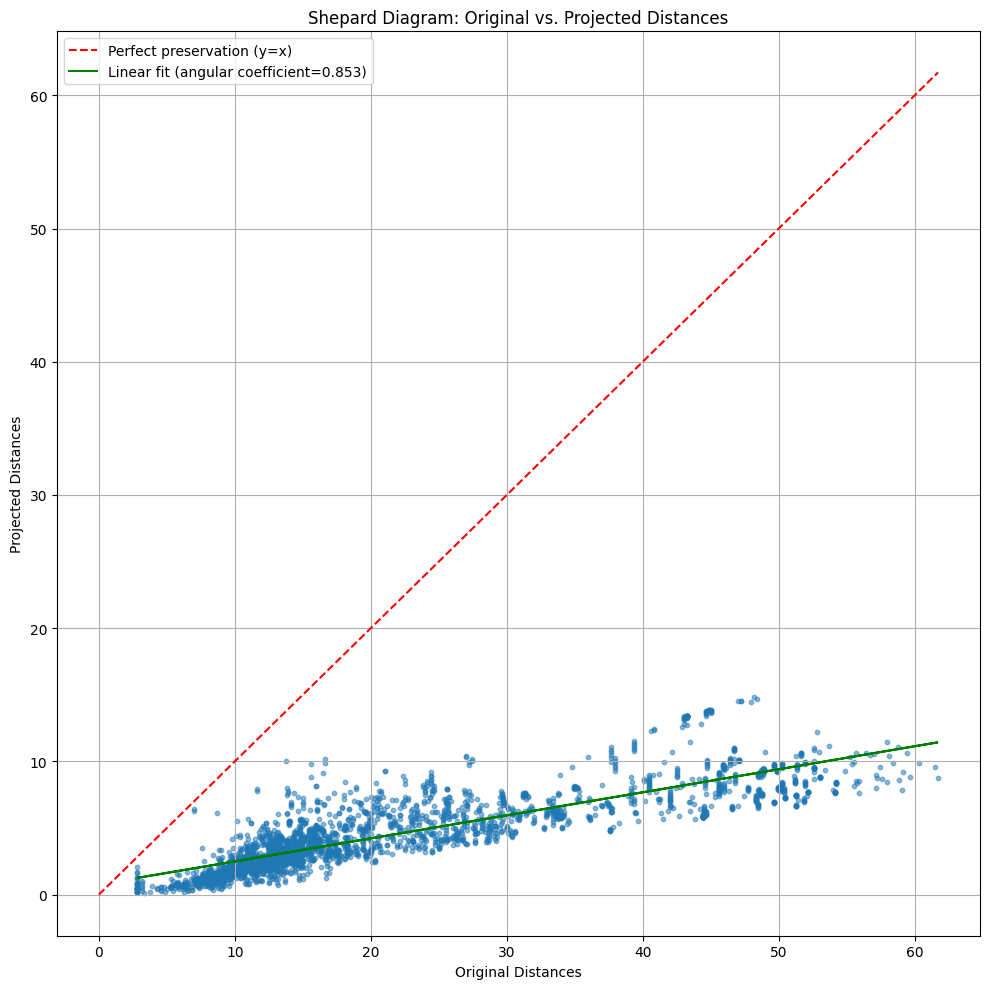

In [24]:
# MDS
fig, ax = plot_shepard_diagram(distance_matrix_np, mds_distance_matrix_reduced)
plt.show()

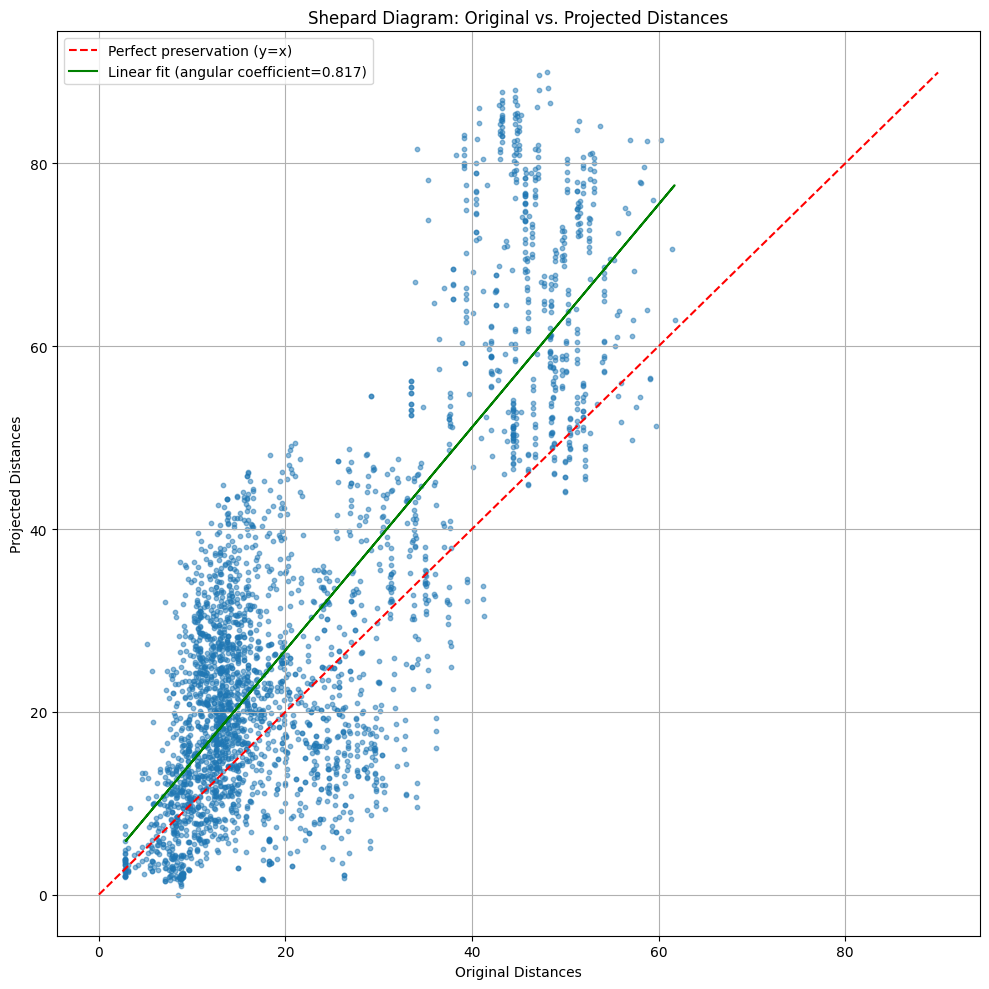

In [27]:
# t-SNE
fig, ax = plot_shepard_diagram(distance_matrix_np, tsne_distance_matrix_reduced)
plt.show()

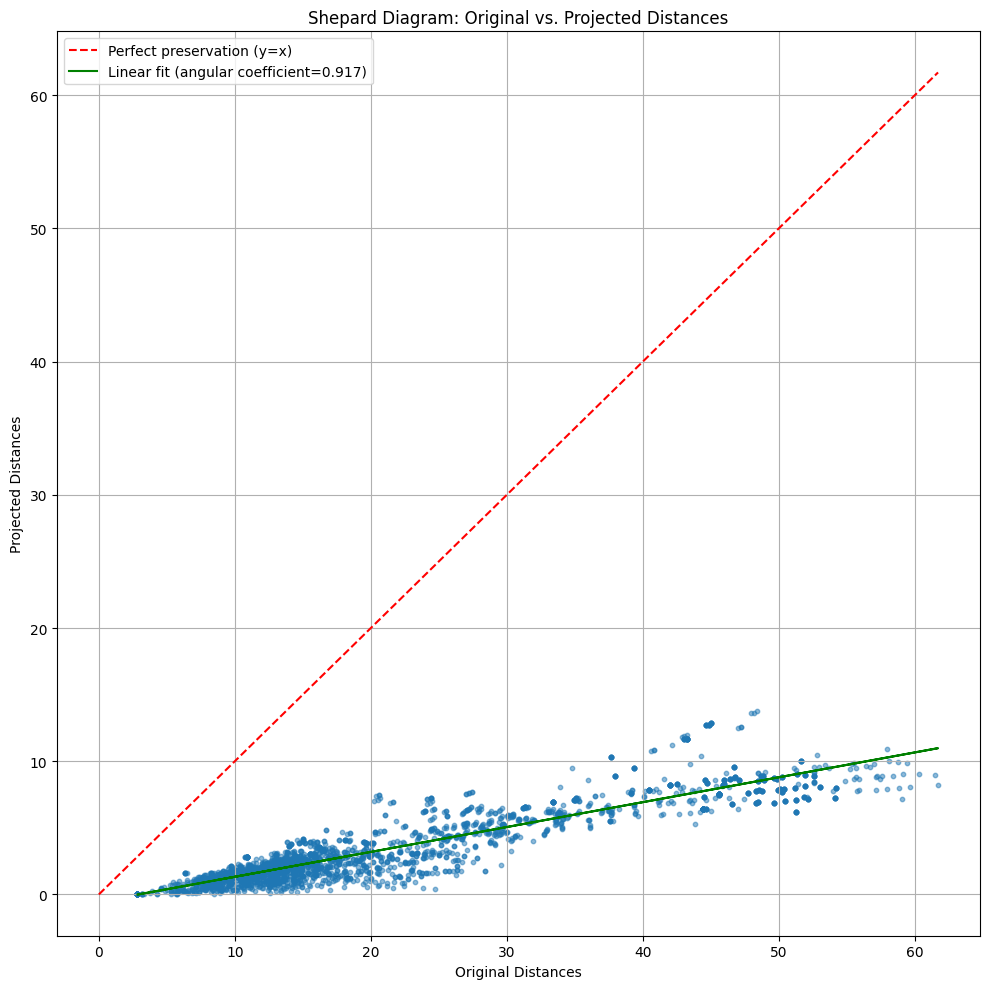

In [25]:
# isomap 2D
fig, ax = plot_shepard_diagram(distance_matrix_np, isomap_distance_matrix_reduced_2d)
plt.show()

## Normalized stress

In [28]:
# MDS
mds_stress = normalized_stress(distance_matrix_np, mds_distance_matrix_reduced)
print(f"Normalized Stress for MDS: {mds_stress:.4f}")

# t-SNE
tsne_stress = normalized_stress(distance_matrix_np, tsne_distance_matrix_reduced)
print(f"Normalized Stress for t-SNE: {tsne_stress:.4f}")

# isomap 2D
isomap_stress = normalized_stress(distance_matrix_np, isomap_distance_matrix_reduced_2d)
print(f"Normalized Stress for isomap: {isomap_stress:.4f}")

Normalized Stress for MDS: 0.6470
Normalized Stress for t-SNE: 0.3023
Normalized Stress for isomap: 0.6925
